Branch
C    7.072866
A    7.027059
B    6.818072
Name: Rating, dtype: float64
Product line
Food and beverages        7.113218
Fashion accessories       7.029213
Health and beauty         7.003289
Electronic accessories    6.924706
Sports and travel         6.916265
Home and lifestyle        6.837500
Name: Rating, dtype: float64


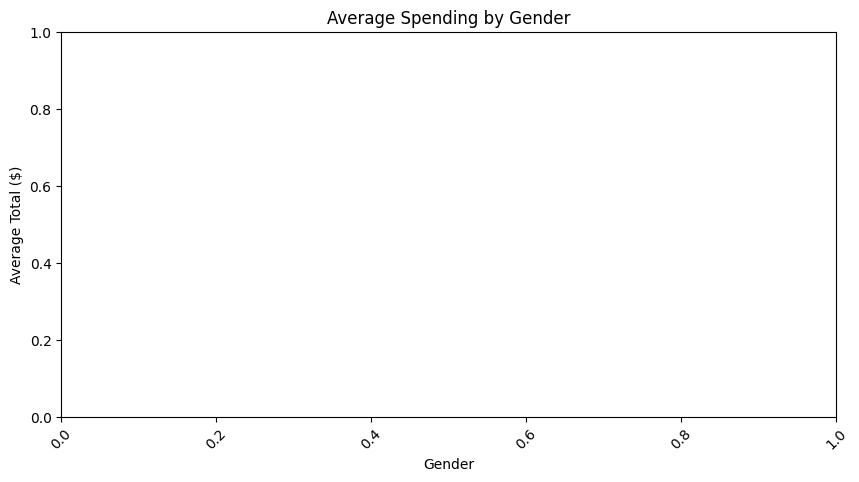

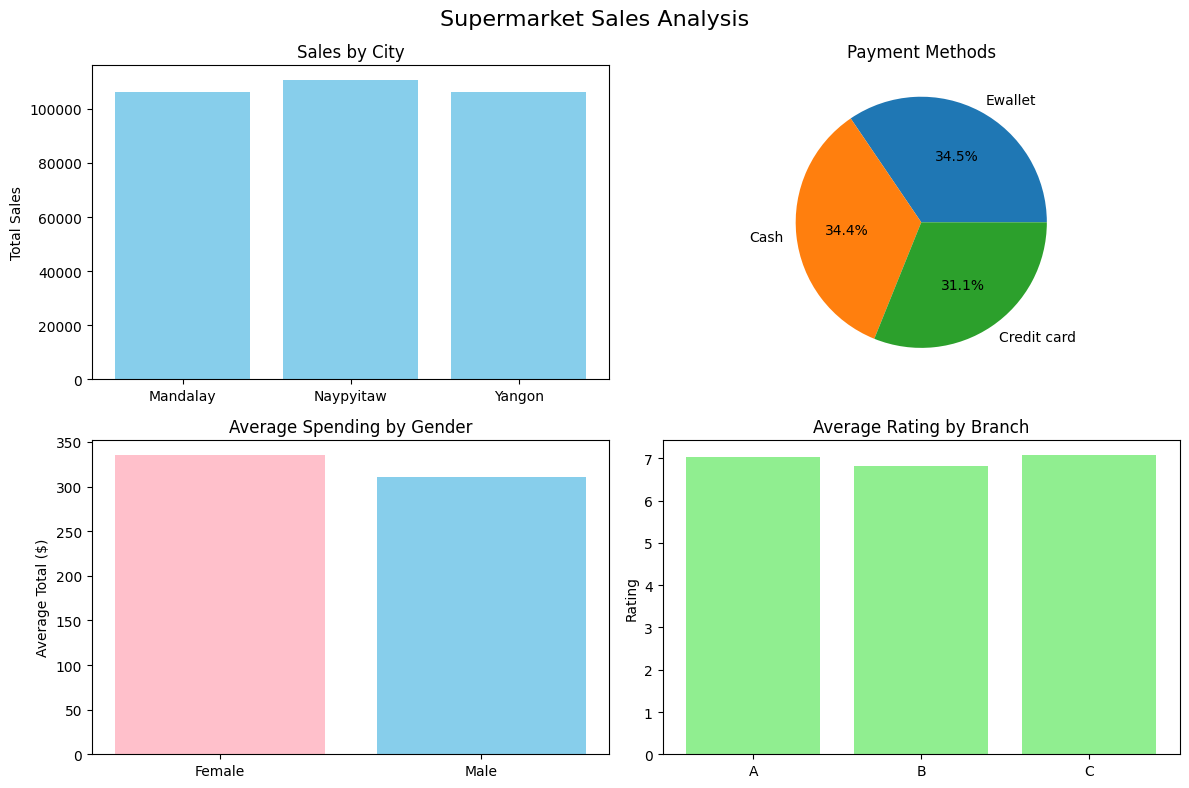

   SUPERMARKET SALES ANALYSIS SUMMARY

 Total Records: 1000
 Total Revenue: $322,966.75
 Average Bill: $322.97

 Top City: Naypyitaw
 Top Product: Food and beverages
 Top Payment: Ewallet
 Top Branch Rating: C



In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load superstore sales dataset
df = pd.read_csv("https://raw.githubusercontent.com/MainakRepositor/Datasets/master/supermarket_sales.csv")




#print(df.shape)
#print(df.head())
#print(df.columns.tolist())
#print(df.isnull().sum())
#print(df.describe())
#which city has the highest sales
#print(df.groupby("City")["Total"].sum().sort_values(ascending=False))
#print(df.groupby("Product line")["Total"].sum().sort_values(ascending=False))
product_sales = df.groupby("Product line")["Total"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
#plt.bar(product_sales.index, product_sales.values, color="skyblue")
plt.title("Total Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
#plt.show()
#print(df["Payment"].value_counts())
payment_counts = df["Payment"].value_counts()

#plt.pie(payment_counts,         labels=payment_counts.index,        autopct="%1.1f%%",        colors=["skyblue", "lightgreen", "orange"])
plt.title("Payment Method Distribution")
#plt.show()
#print(df.groupby("Gender")["Total"].mean())
gender_spend = df.groupby("Gender")["Total"].mean()

#plt.bar(gender_spend.index, gender_spend.values,         color=["pink", "skyblue"])
plt.title("Average Spending by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Total ($)")
#plt.show()
print(df.groupby("Branch")["Rating"].mean().sort_values(ascending=False))
print(df.groupby("Product line")["Rating"].mean().sort_values(ascending=False))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Supermarket Sales Analysis", fontsize=16)

# Chart 1 - Sales by City
city_sales = df.groupby("City")["Total"].sum()
axes[0, 0].bar(city_sales.index, city_sales.values, color="skyblue")
axes[0, 0].set_title("Sales by City")
axes[0, 0].set_ylabel("Total Sales")

# Chart 2 - Payment methods
payment = df["Payment"].value_counts()
axes[0, 1].pie(payment, labels=payment.index, autopct="%1.1f%%")
axes[0, 1].set_title("Payment Methods")

# Chart 3 - Gender spending
gender = df.groupby("Gender")["Total"].mean()
axes[1, 0].bar(gender.index, gender.values, color=["pink", "skyblue"])
axes[1, 0].set_title("Average Spending by Gender")
axes[1, 0].set_ylabel("Average Total ($)")

# Chart 4 - Branch ratings
rating = df.groupby("Branch")["Rating"].mean()
axes[1, 1].bar(rating.index, rating.values, color="lightgreen")
axes[1, 1].set_title("Average Rating by Branch")
axes[1, 1].set_ylabel("Rating")

plt.tight_layout()
plt.show()

print("=" * 40)
print("   SUPERMARKET SALES ANALYSIS SUMMARY")
print("=" * 40)

print(f"\n Total Records: {len(df)}")
print(f" Total Revenue: ${df['Total'].sum():,.2f}")
print(f" Average Bill: ${df['Total'].mean():,.2f}")

print(f"\n Top City: {df.groupby('City')['Total'].sum().idxmax()}")
print(f" Top Product: {df.groupby('Product line')['Total'].sum().idxmax()}")
print(f" Top Payment: {df['Payment'].value_counts().idxmax()}")
print(f" Top Branch Rating: {df.groupby('Branch')['Rating'].mean().idxmax()}")

print("\n" + "=" * 40)